# 0. Generation of the dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


## Read and split data

In [5]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


### Scatter plot on \[i,j\] feature plane

[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


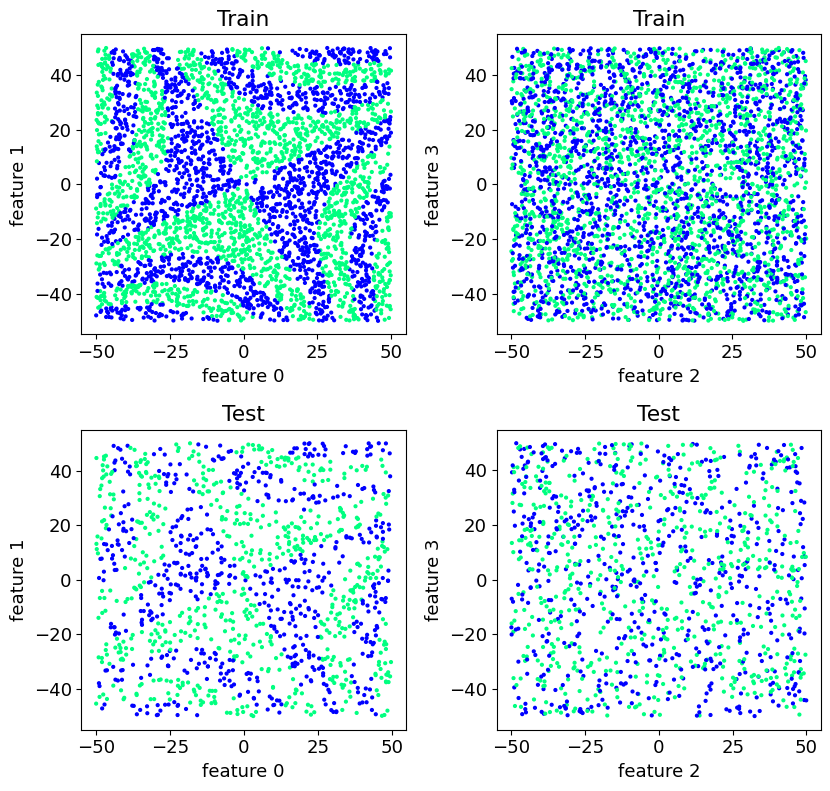

In [6]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_test,y_test,title="Test")
scat(AX[1,1],x_test,y_test,i=2,j=3,title="Test")
fig.tight_layout()
plt.show()

gain
[0.41903338 0.44306126 0.06554136 0.07236399]


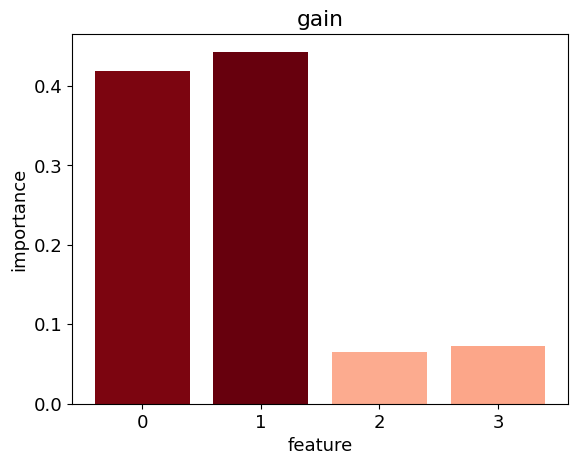

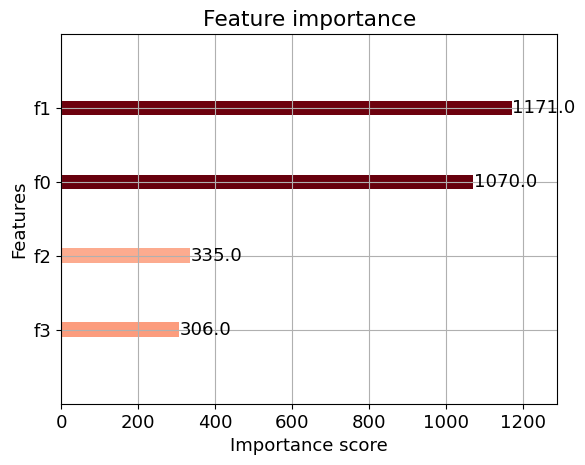

In [10]:
# https://machinelearningmastery.com/feature-importance-and-feature-selection-with-xgboost-in-python/
# feature importance

print(model.importance_type)
print(model.feature_importances_)
# plot
my_cmap = plt.get_cmap("Reds")
# rescale the feature importances to the range [0.3,1] for better visualization
rescale = lambda y: 0.3 + 0.7 * (y - np.min(y)) / (np.max(y) - np.min(y))
plt.bar(range(len(model.feature_importances_)), model.feature_importances_,
        color=my_cmap(rescale(model.feature_importances_)))
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(np.arange(L))
plt.title(model.importance_type)
plt.show()

rescale_r = lambda y: 0.3 + 0.7 * (np.max(y) - y) / (np.max(y) - np.min(y))
plot_importance(model,color=my_cmap(rescale_r(model.feature_importances_)))
plt.show()

In [11]:
def classify(clf=GradientBoostingClassifier()):
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_test) # predict the labels of the test set

    #defining accuracy as a global variable
    global accuracy
    accuracy = clf.score(x_test, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.64%   Accuracy=0.934
shape of x_plot= (10201, 4)


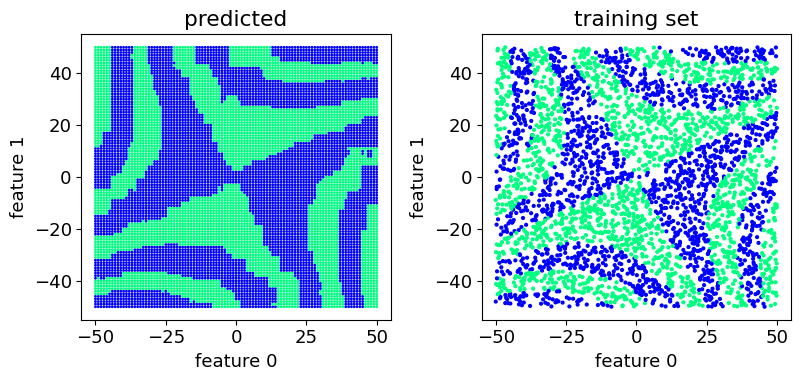

In [12]:
model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify(model)

# 1. Model complexity, parameters and regularization
In this section we will study the accurcy of the model for different parameters


 n_est depth     lr |   train     val     gap
--------------------------------------------------
   200    20   0.10 |  1.0000  0.9408 +0.0592
   100    20   0.30 |  1.0000  0.9400 +0.0600
   400    15   0.05 |  1.0000  0.9400 +0.0600
    50    20   0.30 |  1.0000  0.9392 +0.0608
   100    20   0.10 |  1.0000  0.9392 +0.0608
   400    15   0.10 |  1.0000  0.9384 +0.0616
   400    20   0.10 |  1.0000  0.9384 +0.0616
   100    10   0.30 |  1.0000  0.9376 +0.0624
   200    15   0.05 |  1.0000  0.9376 +0.0624
   200    15   0.10 |  1.0000  0.9376 +0.0624
   200    20   0.30 |  1.0000  0.9376 +0.0624
    50    10   0.30 |  1.0000  0.9368 +0.0632
    50    20   0.10 |  0.9995  0.9368 +0.0627
   400    10   0.10 |  1.0000  0.9368 +0.0632
   400    20   0.05 |  1.0000  0.9368 +0.0632
   100    15   0.30 |  1.0000  0.9360 +0.0640
   200     7   0.10 |  0.9995  0.9360 +0.0635
   200    10   0.10 |  1.0000  0.9360 +0.0640
    50    15   0.30 |  1.0000  0.9352 +0.0648
    50    15   0.50 |  1.0000

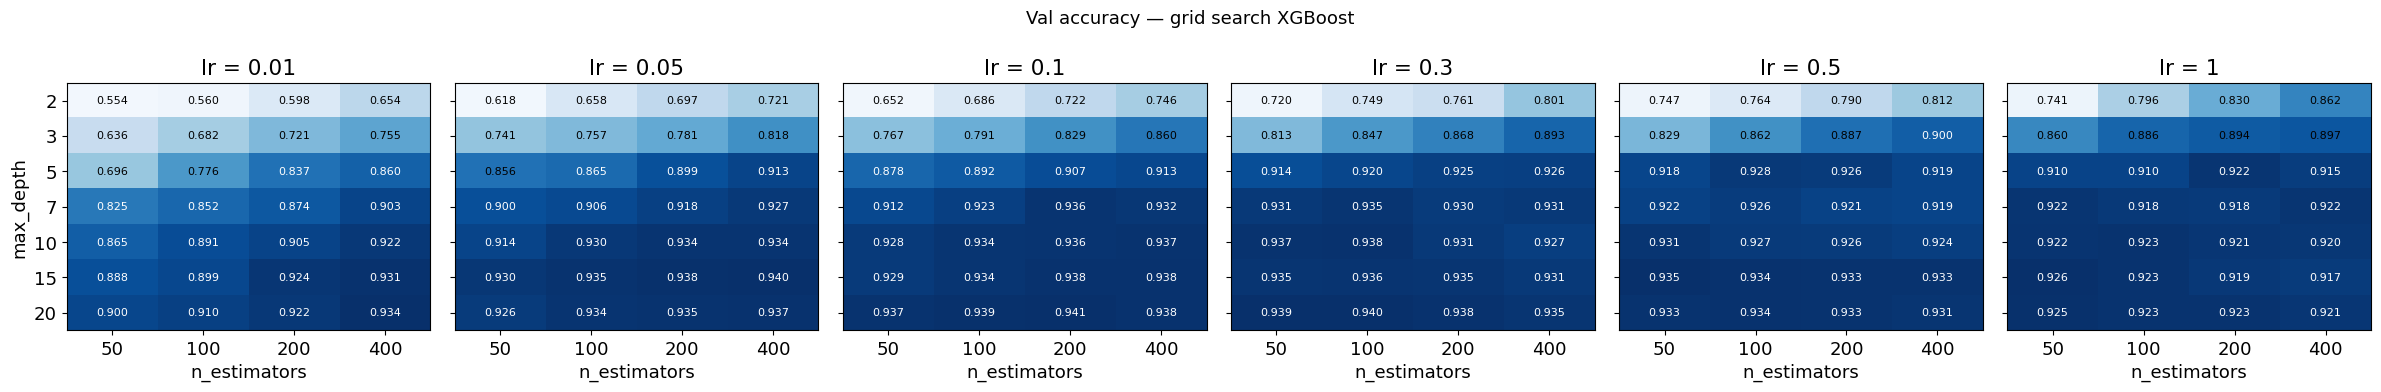

In [18]:
n_estimators_list  = [50, 100, 200, 400]
max_depth_list     = [2, 3, 5, 7, 10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5, 1]
 
results = []
 
for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in  learning_rate_list:
            model = XGBClassifier(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                reg_lambda=1.0,
                gamma=0.0,
                eval_metric="logloss",
                random_state=42,
                verbosity=0,
            )
            model.fit(x_train, y_train)
            acc_train = model.score(x_train, y_train)
            acc_val   = model.score(x_test, y_test)
            results.append((n_est, depth, lr, acc_train, acc_val))
         

results.sort(key=lambda r: -r[4])
 
print(f"{'n_est':>6} {'depth':>5} {'lr':>6} | {'train':>7} {'val':>7} {'gap':>7}")
print("-" * 50)
for n_est, depth, lr, acc_tr, acc_va in results:
    print(f"{n_est:>6} {depth:>5} {lr:>6.2f} | {acc_tr:>7.4f} {acc_va:>7.4f} {acc_tr-acc_va:>+7.4f}")


C:\Users\fardi\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\fardi\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


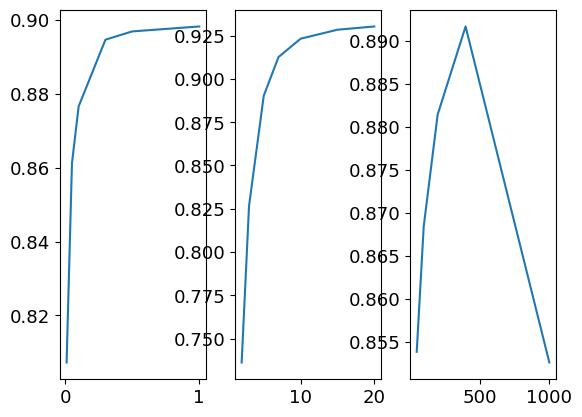

In [46]:
mean_val_vs_lr = []
mean_val_vs_depth = []
mean_val_vs_nest = []
results = np.array(results)

for lr in learning_rate_list:
    mask = results[:,2] == lr
    mean_val_vs_lr.append(np.mean(results[mask, 4]))
    
for depth in max_depth_list:
    mask = results[:,1] == depth
    mean_val_vs_depth.append(np.mean(results[mask, 4]))
    
for n_est in n_estimators_list:
    mask = results[:,0] == n_est
    mean_val_vs_nest.append(np.mean(results[mask, 4]))

fig, axes = plt.subplots(nrows=1,ncols=3)
axes[0].plot(learning_rate_list, mean_val_vs_lr)
axes[1].plot(max_depth_list, mean_val_vs_depth)
axes[2].plot(n_estimators_list, mean_val_vs_nest)


In [47]:
n_estimators_list  = [50, 100, 200, 400, 1000, 2000]
max_depth_list     = [2, 3, 5, 7, 10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5, 1]
 
results = []
 
for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in  learning_rate_list:
            model = XGBClassifier(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                reg_lambda=1.0,
                gamma=0.0,
                eval_metric="logloss",
                random_state=42,
                verbosity=0,
            )
            model.fit(x_train, y_train)
            acc_train = model.score(x_train, y_train)
            acc_val   = model.score(x_test, y_test)
            results.append((n_est, depth, lr, acc_train, acc_val))

KeyboardInterrupt: 

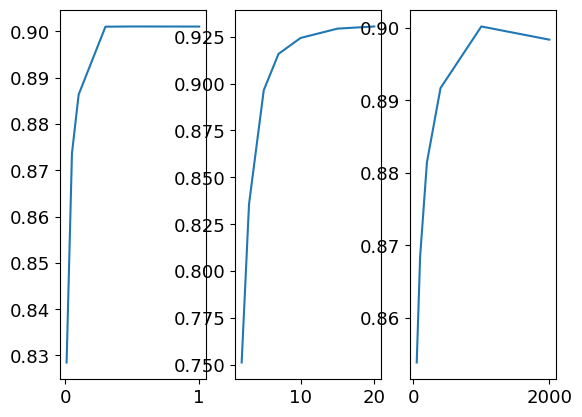

In [48]:
mean_val_vs_lr = []
mean_val_vs_depth = []
mean_val_vs_nest = []
results = np.array(results)

for lr in learning_rate_list:
    mask = results[:,2] == lr
    mean_val_vs_lr.append(np.mean(results[mask, 4]))
    
for depth in max_depth_list:
    mask = results[:,1] == depth
    mean_val_vs_depth.append(np.mean(results[mask, 4]))
    
for n_est in n_estimators_list:
    mask = results[:,0] == n_est
    mean_val_vs_nest.append(np.mean(results[mask, 4]))

fig, axes = plt.subplots(nrows=1,ncols=3)
axes[0].plot(learning_rate_list, mean_val_vs_lr)
axes[1].plot(max_depth_list, mean_val_vs_depth)
axes[2].plot(n_estimators_list, mean_val_vs_nest)


In [60]:
n_estimators  = 400
max_depth     = 15
learning_rate = 0.3
 
results = []
 

model = XGBClassifier(
    seed=1,
    objective='binary:logistic',
    importance_type="gain",
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    reg_lambda=1.0
    
)
model.fit(x_train, y_train)
acc_train = model.score(x_train, y_train)
acc_val   = model.score(x_test, y_test)

print(f"{'n_est':>6} {'depth':>5} {'lr':>6} | {'train':>7} {'val':>7} {'gap':>7}")
print("-" * 50)
print(f"{n_estimators_list:>6} {max_depth_list:>5} {learning_rate_list:>6.2f} | {acc_train:>7.4f} {acc_val:>7.4f} {acc_train-acc_val:>+7.4f}")


 n_est depth     lr |   train     val     gap
--------------------------------------------------
   400    15   0.30 |  1.0000  0.9312 +0.0688


0.001	0.9312
0.01	0.9312
0.1	0.9312
0.4	0.9344
0.5	0.9344
0.6	0.9304
0.7	0.928
1	0.9312
3	0.936
7	0.9344
10	0.936
30	0.9296
100	0.928
300	0.9144


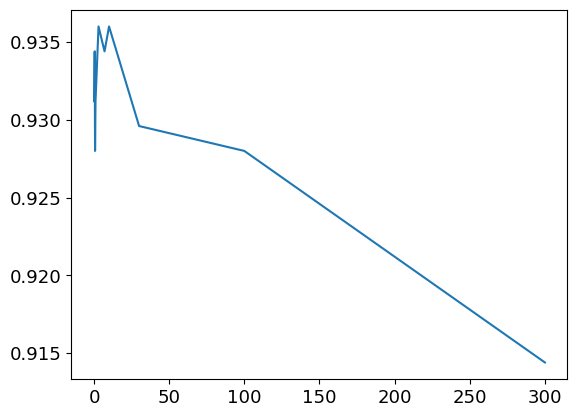

In [69]:
lambda_val_list = [0.001, 0.01, 0.1, 0.4, 0.5, 0.6 ,0.7, 1, 3, 7, 10, 30, 100, 300]
res = []

for l in lambda_val_list:
    model = XGBClassifier(
    seed=1,
    objective='binary:logistic',
    importance_type="gain",
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    reg_lambda=l
    )
    model.fit(x_train, y_train)
    acc_train = model.score(x_train, y_train)
    acc_val   = model.score(x_test, y_test)
    print(l, acc_val, sep="\t")
    res.append(acc_val)

fig, ax = plt.subplots(nrows=1,ncols=1)
ax.plot(lambda_val_list, res)

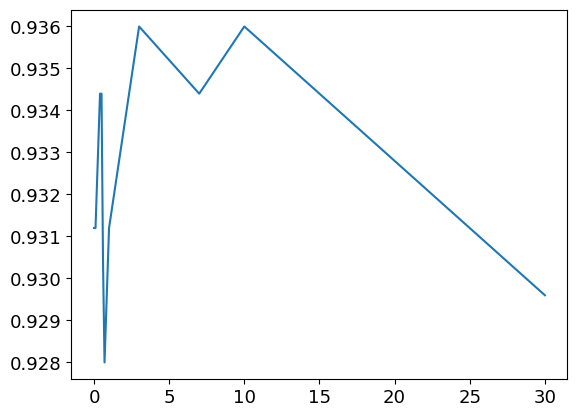

In [72]:
fig, ax = plt.subplots(nrows=1,ncols=1)
ax.plot(lambda_val_list[:-2], res[:-2])

# 2. 

In [56]:
#redefining x_train and x_test without the feauture 3
x_train_012 = x_train[:, :3]
x_test_012 = x_test[:, :3]

In [57]:
#redifining the classification with the new datasets of training and test
def classify_012(clf=GradientBoostingClassifier()):

    clf.fit(x_train_012,y_train) 
    y_hat = clf.predict(x_test_012) 

    global accuracy_012
    accuracy_012 = clf.score(x_test_012, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_012, y_test)),clf.score(x_test_012, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-1))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_012[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.88%   Accuracy=0.931
shape of x_plot= (10201, 3)


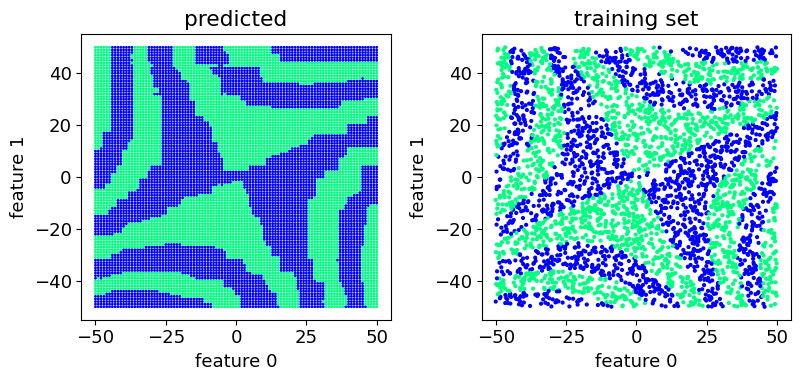

In [78]:
model_012 = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify_012(model_012)

In [59]:
#redefining x_train and x_test without the feauture 3 and 2
x_train_01 = x_train[:, :2]
x_test_01 = x_test[:, :2]

In [60]:
#redifining the classification with the new datasets of training and test
def classify_01(clf=GradientBoostingClassifier()):

    clf.fit(x_train_01,y_train) 
    y_hat = clf.predict(x_test_01) 

    global accuracy_01
    accuracy_01 = clf.score(x_test_01, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_01, y_test)),clf.score(x_test_01, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-2))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_01[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.24%   Accuracy=0.938
shape of x_plot= (10201, 2)


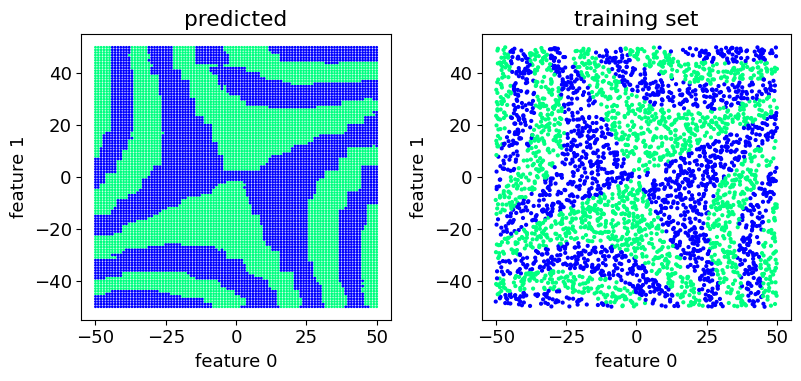

In [77]:
model_01 = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify_01(model_01)

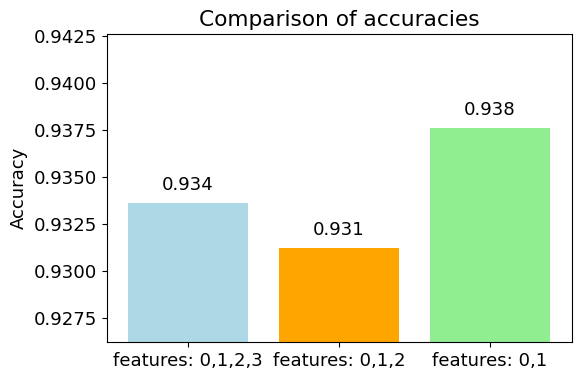

In [76]:
plt.figure(figsize=(6,4))
bars = plt.bar(labels, accuracies, color=['lightblue','orange','lightgreen'])
accuracies = [accuracy, accuracy_012, accuracy_01]
labels = ['features: 0,1,2,3', 'features: 0,1,2', 'features: 0,1']
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.3f}", ha='center', va='bottom')


plt.ylim(min(accuracies)-0.005, max(accuracies)+0.005) 
plt.ylabel("Accuracy")
plt.title("Comparison of accuracies")
plt.show()

## Comment on accuracies
As we can see from the plot the accuracy using only feautures 0 and 1 is higher than the others, that's because feutures 2 and 3 are not informative about the dataset. Removing only the third feature doesn't improve the accuracy because of the stochastic process introduced by feature 2. 